In [105]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [3]:
import medmnist
from medmnist import INFO, Evaluator

In [86]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

should we change CrossEntropyLoss to use class weight?

In [6]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [71]:
from sklearn.utils.class_weight import compute_class_weight
all_labels = train_dataset.labels.squeeze()
class_weights = compute_class_weight(class_weight='balanced', classes=np.arange(7), y=all_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

In [95]:
def default_setup(lr=0.001, l2_weight=0.0, rho_init=-2.25):
    model = VariationalCNN(n_channels, n_classes, rho_init=rho_init)
    # criterion = nn.CrossEntropyLoss(weight=class_weights)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_weight)
    return model, criterion, optimizer

In [32]:
RANDOM_SEED = 42

## First we tried the BCNN naively

In [96]:
# Create SSL versions of our datasets
unlabeled_rate = 0.5

train_labels_ssl_50 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_50 = SSLDataset(train_dataset, train_labels_ssl_50)
train_ssl_loader_50 = data.DataLoader(train_ssl_dataset_50, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.5 | Total examples: 7007 | Labeled examples: 3506 | Unlabeled examples: 3501
Class 0: 114/228 labeled, 114 unlabeled
Class 1: 180/359 labeled, 179 unlabeled
Class 2: 385/769 labeled, 384 unlabeled
Class 3: 40/80 labeled, 40 unlabeled
Class 4: 390/779 labeled, 389 unlabeled
Class 5: 2347/4693 labeled, 2346 unlabeled
Class 6: 50/99 labeled, 49 unlabeled


In [97]:
ssl_bmodel_50, criterion, optimizer = default_setup(lr=0.001)
bcnn_history_50 = train_loop_bcnn_hard_pseudo_label(ssl_bmodel_50, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=30, alpha=0.5, beta=1.0, threshold=0.95, num_samples=10)

#after training
# for name, param in ssl_bmodel_50.named_parameters():
#     print(f"{name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")


beta:1.0


100%|██████████| 8/8 [00:01<00:00,  4.19it/s]


Epoch 1/30 | Train NLL: 1.5189 | Train KL (avg/batch): 0.9019 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/3501 | Val Loss: 1.1598 | Val AUC Macro: 0.5022 | Val AUC Global: 0.8683


100%|██████████| 8/8 [00:01<00:00,  4.34it/s]


Epoch 2/30 | Train NLL: 1.2990 | Train KL (avg/batch): 0.9017 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/3501 | Val Loss: 1.1475 | Val AUC Macro: 0.5195 | Val AUC Global: 0.8763


...

Epoch 28/30 | Train NLL: 0.8579 | Train KL (avg/batch): 0.8889 | Train Loss Unlabeled: 0.0788 | Unlabeled Examples Used: 1084/3501 | Val Loss: 0.8670 | Val AUC Macro: 0.8451 | Val AUC Global: 0.9386


100%|██████████| 8/8 [00:01<00:00,  4.31it/s]


Epoch 29/30 | Train NLL: 0.8748 | Train KL (avg/batch): 0.8882 | Train Loss Unlabeled: 0.0728 | Unlabeled Examples Used: 1135/3501 | Val Loss: 0.9166 | Val AUC Macro: 0.8259 | Val AUC Global: 0.9314


100%|██████████| 8/8 [00:01<00:00,  4.25it/s]


Epoch 30/30 | Train NLL: 0.8500 | Train KL (avg/batch): 0.8874 | Train Loss Unlabeled: 0.0716 | Unlabeled Examples Used: 1099/3501 | Val Loss: 0.9021 | Val AUC Macro: 0.8370 | Val AUC Global: 0.9340


In [98]:
ssl_bmodel_50.eval()
all_max_probs = []
with torch.no_grad():
    for images, labels in train_ssl_loader_50:
        unlabeled_mask = (labels == -1).squeeze()
        inputs_unlabeled = images[unlabeled_mask]
        if inputs_unlabeled.size(0) > 0:
            avg_probs = ssl_bmodel_50.average_probs(inputs_unlabeled, num_samples=10)
            max_probs, _ = torch.max(avg_probs, dim=1)
            all_max_probs.append(max_probs)

all_max_probs = torch.cat(all_max_probs)
print(f"Mean: {all_max_probs.mean():.3f}")
print(f"Max: {all_max_probs.max():.3f}")
print(f"% > 0.95: {(all_max_probs > 0.95).float().mean()*100:.1f}%")
print(f"% > 0.80: {(all_max_probs > 0.80).float().mean()*100:.1f}%")
print(f"% > 0.70: {(all_max_probs > 0.70).float().mean()*100:.1f}%")

Mean: 0.710
Max: 0.989
% > 0.95: 4.3%
% > 0.80: 38.0%
% > 0.70: 60.3%


In [99]:
best_ssl_history_50 = max(bcnn_history_50, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_ssl_history_50['epoch']} | Val AUC Macro: {best_ssl_history_50['val_auc_macro']:.4f}")

best_bcnn_model_50 = VariationalCNN(n_channels, n_classes)
best_bcnn_model_50.load_state_dict(best_ssl_history_50['model_state'])

Best Epoch: 28 | Val AUC Macro: 0.8451


<All keys matched successfully>

In [100]:
[h['train_total_unlabeled'] for h in bcnn_history_50]

[0,
 0,
 0,
 0,
 9,
 22,
 221,
 821,
 944,
 850,
 885,
 1006,
 1049,
 1031,
 942,
 1119,
 1019,
 1116,
 1134,
 1114,
 1136,
 1106,
 1085,
 1084,
 1088,
 1116,
 1114,
 1084,
 1135,
 1099]

In [1]:
test_results_bcnn_50 = evaluate_bayesian(best_bcnn_model_50, test_loader, device='cpu')
test_results_bcnn_50

NameError: name 'evaluate_bayesian' is not defined

In [102]:
with torch.no_grad():
    best_bcnn_model_50.eval()
    probs, targets = [], []
    for images, labels in tqdm(test_loader):
        images = images.to('cpu')
        mean_probs = best_bcnn_model_50.average_probs(images, num_samples=10)
        probs.append(mean_probs.cpu().numpy())
        targets.append(labels.squeeze().cpu().numpy())

probs = np.concatenate(probs)
targets = np.concatenate(targets)
preds = np.argmax(probs, axis=1)
print(f"Percentage of predictions that are class 5: {(preds == 5).mean() * 100:.1f}%")

100%|██████████| 8/8 [00:02<00:00,  2.98it/s]

Percentage of predictions that are class 5: 91.2%


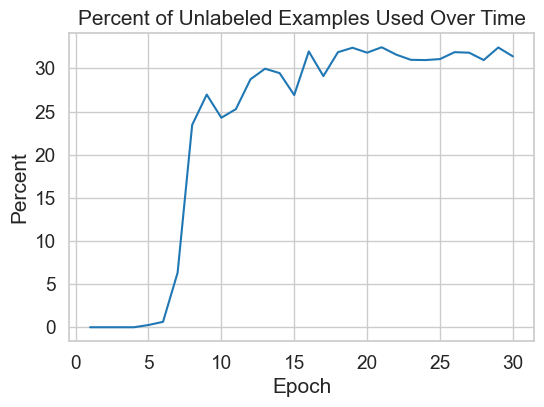

In [103]:
plot_percent_unlabeled_used(bcnn_history_50)

In [104]:
# after training, run one pass through unlabeled data
best_bcnn_model_50.eval()
all_pseudo_labels = []
with torch.no_grad():
    for images, labels in train_ssl_loader_50:
        unlabeled_mask = (labels == -1).squeeze()
        inputs_unlabeled = images[unlabeled_mask]
        if inputs_unlabeled.size(0) > 0:
            avg_probs = best_bcnn_model_50.average_probs(inputs_unlabeled, num_samples=10)
            max_probs, pseudo_labels = torch.max(avg_probs, dim=1)
            confident = max_probs >= 0.95
            if confident.sum() > 0:
                all_pseudo_labels.append(pseudo_labels[confident])
all_pseudo_labels = torch.cat(all_pseudo_labels)
print(np.bincount(all_pseudo_labels.numpy(), minlength=7) / len(all_pseudo_labels))

[0. 0. 0. 0. 0. 1. 0.]


## Problem: Only pseudo labels that pass threshold are the majority class

#### So the problem: it's always predicting majority class

## Next, we tried taking out the KL divergence loss by setting beta=0, and switched back to fully supervised dataset for debugging

In [15]:
# Create SSL versions of our datasets
unlabeled_rate = 0.0

train_labels_ssl_00 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_00 = SSLDataset(train_dataset, train_labels_ssl_00)
train_ssl_loader_00 = data.DataLoader(train_ssl_dataset_00, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.0 | Total examples: 7007 | Labeled examples: 7007 | Unlabeled examples: 0
Class 0: 228/228 labeled, 0 unlabeled
Class 1: 359/359 labeled, 0 unlabeled
Class 2: 769/769 labeled, 0 unlabeled
Class 3: 80/80 labeled, 0 unlabeled
Class 4: 779/779 labeled, 0 unlabeled
Class 5: 4693/4693 labeled, 0 unlabeled
Class 6: 99/99 labeled, 0 unlabeled


In [56]:
ssl_bmodel_00, criterion, optimizer = default_setup(lr=0.001)
bcnn_history_00 = train_loop_bcnn_hard_pseudo_label(ssl_bmodel_00, train_ssl_loader_00, val_loader, criterion, optimizer, num_epochs=20, alpha=0.5, beta=0.0, num_samples=10)

beta:0.0


100%|██████████| 8/8 [00:01<00:00,  4.38it/s]


Epoch 1/20 | Train NLL: 1.5148 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 1.1542 | Val AUC Macro: 0.5005 | Val AUC Global: 0.8719


100%|██████████| 8/8 [00:01<00:00,  4.35it/s]


Epoch 2/20 | Train NLL: 1.3125 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 1.1819 | Val AUC Macro: 0.4968 | Val AUC Global: 0.8681


...

Epoch 18/20 | Train NLL: 0.9006 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 0.8625 | Val AUC Macro: 0.8342 | Val AUC Global: 0.9393


100%|██████████| 8/8 [00:01<00:00,  4.01it/s]


Epoch 19/20 | Train NLL: 0.8842 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 0.8647 | Val AUC Macro: 0.8422 | Val AUC Global: 0.9383


100%|██████████| 8/8 [00:02<00:00,  3.92it/s]

Epoch 20/20 | Train NLL: 0.8808 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 0.8707 | Val AUC Macro: 0.8423 | Val AUC Global: 0.9373


In [57]:
best_ssl_history_00 = max(bcnn_history_00, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_ssl_history_00['epoch']} | Val AUC Macro: {best_ssl_history_00['val_auc_macro']:.4f}")

best_bcnn_model_00 = VariationalCNN(n_channels, n_classes)
best_bcnn_model_00.load_state_dict(best_ssl_history_00['model_state'])

Best Epoch: 20 | Val AUC Macro: 0.8423


<All keys matched successfully>

In [58]:
with torch.no_grad():
    best_bcnn_model_00.eval()
    probs, targets = [], []
    for images, labels in tqdm(test_loader):
        images = images.to('cpu')
        mean_probs = best_bcnn_model_00.average_probs(images, num_samples=10)
        probs.append(mean_probs.cpu().numpy())
        targets.append(labels.squeeze().cpu().numpy())

probs = np.concatenate(probs)
targets = np.concatenate(targets)
preds = np.argmax(probs, axis=1)
print(f"Percentage of predictions that are class 5: {(preds == 5).mean() * 100:.1f}%")

100%|██████████| 8/8 [00:02<00:00,  2.92it/s]

Percentage of predictions that are class 5: 88.7%


#### Removing KL term and switching to fully supervised doesn't fix the issue. Still 100% majority class prediction

## Let's look at predictions of an untrained network on initialization

In [33]:
model, criterion, optimizer = default_setup(lr=0.0001, rho_init=-2.25)
images, labels = next(iter(test_loader))

with torch.no_grad():
    logits = model(images[:5])
    probs = torch.softmax(logits, dim=1)
    print("Logits:", logits)
    print("Probs:", probs)
    print("Preds:", probs.argmax(dim=1))
    print("True:", labels[:5].squeeze())

rho_init conv: -2.25
rho_init conv: -2.25
rho_init conv: -2.25
rho_init conv: -2.25
rho_init conv: -2.25
rho_init lin: -2.25
rho_init lin: -2.25
rho_init lin: -2.25
Logits: tensor([[-6.3469, 13.2949, -3.8732, -7.3352,  4.8960, -3.2899, -0.1362],
        [ 0.4668,  4.4479,  5.9930, -2.7750,  3.4404,  3.1903, -0.1789],
        [ 3.4226,  2.7751,  5.4497, -1.2336,  2.8133,  2.1623, -4.0212],
        [-2.3246,  2.9908,  4.1663,  2.1572,  2.4351,  4.7785, -1.0429],
        [-2.6660,  9.2819,  6.3380,  1.0731,  8.0306, 11.0252, -5.8700]])
Probs: tensor([[2.9484e-09, 9.9977e-01, 3.4985e-08, 1.0974e-09, 2.2506e-04, 6.2689e-08,
         1.4684e-06],
        [2.9315e-03, 1.5706e-01, 7.3636e-01, 1.1460e-04, 5.7346e-02, 4.4655e-02,
         1.5369e-03],
        [1.0047e-01, 5.2583e-02, 7.6281e-01, 9.5478e-04, 5.4632e-02, 2.8490e-02,
         5.8783e-05],
        [4.3705e-04, 8.8918e-02, 2.8806e-01, 3.8633e-02, 5.1010e-02, 5.3137e-01,
         1.5746e-03],
        [9.1744e-07, 1.4174e-01, 7.4645e-0

#### So it is not immediately predicting class 5 all the time. That must be learned during training
#### What happens after 1 epoch?

In [38]:
model, criterion, optimizer = default_setup(lr=0.0001, rho_init=-2.25)
history = train_loop_bcnn_hard_pseudo_label(model, train_loader, val_loader, criterion, optimizer, num_epochs=1, alpha=0.5, beta=0.0, num_samples=10)

rho_init conv: -2.25
rho_init conv: -2.25
rho_init conv: -2.25
rho_init conv: -2.25
rho_init conv: -2.25
rho_init lin: -2.25
rho_init lin: -2.25
rho_init lin: -2.25
beta:0.0


100%|██████████| 8/8 [00:01<00:00,  4.00it/s]


Epoch 1/1 | Train NLL: 4.9460 | Train KL (avg/batch): 0.0000 | Train Loss Unlabeled: 0.0000 | Val Loss: 1.5778 | Val AUC Macro: 0.5058 | Val AUC Global: 0.8122


In [39]:
images, labels = next(iter(test_loader))
with torch.no_grad():
    logits = model(images[:5])
    probs = torch.softmax(logits, dim=1)
    print("Logits:", logits)
    print("Probs:", probs)
    print("Preds after 1 epoch:", probs.argmax(dim=1).numpy())
    print("True:", labels[:5].squeeze().numpy())

Logits: tensor([[  0.9704,  -1.9019,  -6.7771,  -4.4440,  -7.6084,  12.3334,   7.8532],
        [  2.5982,  -5.9419,  -3.8602,  -2.5993,  -7.4715,   0.7541,  -0.9868],
        [ -3.0160,  -1.4816,  -4.4813,  -7.5223,  -7.8985,   4.6233,   0.3199],
        [ -1.7482,  -3.9558,  -5.2090,  -2.7149,  -7.7847,  -0.7233,   2.7602],
        [  5.2170,  -6.6861, -12.2378,   4.5290,  -8.6384,  10.5464,  -4.6698]])
Probs: tensor([[1.1486e-05, 6.4978e-07, 4.9605e-09, 5.1140e-08, 2.1602e-09, 9.8878e-01,
         1.1204e-02],
        [8.3805e-01, 1.6381e-04, 1.3134e-03, 4.6345e-03, 3.5485e-05, 1.3255e-01,
         2.3245e-02],
        [4.7345e-04, 2.1961e-03, 1.0937e-04, 5.2267e-06, 3.5876e-06, 9.8391e-01,
         1.3305e-02],
        [1.0516e-02, 1.1564e-03, 3.3027e-04, 3.9997e-03, 2.5132e-05, 2.9307e-02,
         9.5466e-01],
        [4.8119e-03, 3.2575e-08, 1.2642e-10, 2.4185e-03, 4.6239e-09, 9.9277e-01,
         2.4465e-07]])
Preds after 1 epoch: [5 0 5 6 5]
True: [5 3 4 0 5]


## So the logits are becoming extremely confident, often in the wrong case. Why? What are the gradients?

In [45]:
model, criterion, optimizer = default_setup(lr=0.0001, rho_init=-2.25)
images, labels = next(iter(train_loader))
label_mask = (labels != -1).squeeze()
inputs = images[label_mask]
targets = labels[label_mask].squeeze().long()

outputs = model(inputs)
loss = criterion(outputs, targets)
loss.backward()

print(f"mu_w grad layer1: {model.layer1[0].mu_w.grad.abs().mean():.6f}")
print(f"r_w grad layer1: {model.layer1[0].r_w.grad.abs().mean():.6f}")
print(f"mu_w grad fc final: {model.fc[4].mu_w.grad.abs().mean():.6f}")

mu_w grad layer1: 0.133444
r_w grad layer1: 0.010365
mu_w grad fc final: 0.143343


#### What did it look like on our working CNN for reference?

In [46]:
from cnn import CNN
ref_model = CNN(n_channels, n_classes)
images, labels = next(iter(train_loader))
targets = labels.squeeze().long()
outputs = ref_model(images)
loss = criterion(outputs, targets)
loss.backward()
print(f"mu_w grad layer1: {ref_model.layer1[0].weight.grad.abs().mean():.6f}")
print(f"mu_w grad fc final: {ref_model.fc[2].weight.grad.abs().mean():.6f}")

mu_w grad layer1: 0.008225
mu_w grad fc final: 0.002017


#### So gradients on our BCNN are much higher (100x) than the baseline CNN

In [47]:
images, labels = next(iter(train_loader))
label_mask = (labels != -1).squeeze()
inputs = images[label_mask]

# Regular CNN
ref_model = CNN(n_channels, n_classes)
with torch.no_grad():
    x1 = ref_model.layer1(inputs)
    x2 = ref_model.layer2(x1)
    x3 = ref_model.layer3(x2)
    x4 = ref_model.layer4(x3)
    x5 = ref_model.layer5(x4)
    xf = x5.view(x5.size(0), -1)
    out = ref_model.fc(xf)
    print("CNN:")
    print(f"  Layer 1: mean={x1.mean():.4f}, std={x1.std():.4f}")
    print(f"  Layer 5: mean={x5.mean():.4f}, std={x5.std():.4f}")
    print(f"  Logits:  mean={out.mean():.4f}, std={out.std():.4f}")

# BCNN
model, criterion, optimizer = default_setup(lr=0.0001, rho_init=-2.25)
with torch.no_grad():
    x1 = model.layer1(inputs)
    x2 = model.layer2(x1)
    x3 = model.layer3(x2)
    x4 = model.layer4(x3)
    x5 = model.layer5(x4)
    xf = x5.view(x5.size(0), -1)
    out = model.fc(xf)
    print("BCNN:")
    print(f"  Layer 1: mean={x1.mean():.4f}, std={x1.std():.4f}")
    print(f"  Layer 5: mean={x5.mean():.4f}, std={x5.std():.4f}")
    print(f"  Logits:  mean={out.mean():.4f}, std={out.std():.4f}")

CNN:
  Layer 1: mean=0.3919, std=0.5758
  Layer 5: mean=0.7498, std=0.7755
  Logits:  mean=0.0376, std=0.0705
BCNN:
  Layer 1: mean=0.3896, std=0.6020
  Layer 5: mean=0.7422, std=0.7638
  Logits:  mean=5.5289, std=6.2003


### Seems like the FC layer in the BCNN is exploding the logits

In [48]:
images, labels = next(iter(train_loader))
label_mask = (labels != -1).squeeze()
inputs = images[label_mask]

model, criterion, optimizer = default_setup(lr=0.0001, rho_init=-2.25)

with torch.no_grad():
    # get conv output
    x = model.layer1(inputs)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4(x)
    x = model.layer5(x)
    x = x.view(x.size(0), -1)
    print(f"After flatten: mean={x.mean():.4f}, std={x.std():.4f}")
    
    x = model.fc[0](x)  # first linear layer
    print(f"After fc[0]: mean={x.mean():.4f}, std={x.std():.4f}")
    
    x = torch.relu(x)
    print(f"After relu: mean={x.mean():.4f}, std={x.std():.4f}")
    
    x = model.fc[2](x)  # second linear layer
    print(f"After fc[2]: mean={x.mean():.4f}, std={x.std():.4f}")
    
    x = torch.relu(x)
    print(f"After relu: mean={x.mean():.4f}, std={x.std():.4f}")
    
    x = model.fc[4](x)  # third linear layer
    print(f"After fc[4]: mean={x.mean():.4f}, std={x.std():.4f}")

After flatten: mean=0.7373, std=0.7349
After fc[0]: mean=-0.3996, std=3.5852
After relu: mean=1.2130, std=1.9762
After fc[2]: mean=-0.2415, std=4.0483
After relu: mean=1.4461, std=2.3230
After fc[4]: mean=0.0142, std=5.5906


In [49]:
ref_model = CNN(n_channels, n_classes)

with torch.no_grad():
    x = ref_model.layer1(inputs)
    x = ref_model.layer2(x)
    x = ref_model.layer3(x)
    x = ref_model.layer4(x)
    x = ref_model.layer5(x)
    x = x.view(x.size(0), -1)
    print(f"After flatten: mean={x.mean():.4f}, std={x.std():.4f}")
    
    x = ref_model.fc[0](x)
    print(f"After fc[0]: mean={x.mean():.4f}, std={x.std():.4f}")
    
    x = torch.relu(x)
    print(f"After relu: mean={x.mean():.4f}, std={x.std():.4f}")
    
    x = ref_model.fc[2](x)
    print(f"After fc[2]: mean={x.mean():.4f}, std={x.std():.4f}")
    
    x = torch.relu(x)
    print(f"After relu: mean={x.mean():.4f}, std={x.std():.4f}")
    
    x = ref_model.fc[4](x)
    print(f"After fc[4]: mean={x.mean():.4f}, std={x.std():.4f}")

After flatten: mean=0.7594, std=0.7543
After fc[0]: mean=-0.0151, std=0.6449
After relu: mean=0.2411, std=0.3852
After fc[2]: mean=0.0126, std=0.2637
After relu: mean=0.1084, std=0.1665
After fc[4]: mean=0.0062, std=0.1174


## Tentative conclusion: it seems like our stddev is exploding in the fully connected layers

Thinking this through, if we look at how the variance explodes through our FC layers, the kaiming initialization doesn't account for the extra variance term which is a result of the extra noise term scaled by sigma_w. 

to get some output vector entry, we sum up 1024 terms (using the first FC layer as an example), so we get this exploding variance. 

possible solution: introduce LayerNorm after each FC layer, to rescale the activation to approx? N(0,1)

In [53]:
images, labels = next(iter(train_loader))
label_mask = (labels != -1).squeeze()
inputs = images[label_mask]

model, criterion, optimizer = default_setup(lr=0.0001, rho_init=-2.25)

with torch.no_grad():
    # get conv output
    x = model.layer1(inputs)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4(x)
    x = model.layer5(x)
    x = x.view(x.size(0), -1)
    print(f"After flatten: mean={x.mean():.4f}, std={x.std():.4f}")
    
    x = model.fc[0](x)  # first linear layer
    print(f"After fc[0]: mean={x.mean():.4f}, std={x.std():.4f}")

    x = model.fc[1](x)  # layernorm
    print(f"After layernorm: mean={x.mean():.4f}, std={x.std():.4f}")

    x = model.fc[2](x)  # relu
    print(f"After relu: mean={x.mean():.4f}, std={x.std():.4f}")

    x = model.fc[3](x)  # second linear layer
    print(f"After fc[3]: mean={x.mean():.4f}, std={x.std():.4f}")

    x = model.fc[4](x)  # layernorm
    print(f"After layernorm: mean={x.mean():.4f}, std={x.std():.4f}")

    x = model.fc[5](x)  # relu
    print(f"After relu: mean={x.mean():.4f}, std={x.std():.4f}")

    x = model.fc[6](x)  # third linear layer
    print(f"After fc[6]: mean={x.mean():.4f}, std={x.std():.4f}")

After flatten: mean=0.7596, std=0.7457
After fc[0]: mean=0.3841, std=3.8337
After layernorm: mean=0.0000, std=1.0000
After relu: mean=0.4027, std=0.5836
After fc[3]: mean=0.0848, std=1.3273
After layernorm: mean=0.0000, std=1.0000
After relu: mean=0.4032, std=0.5893
After fc[6]: mean=0.5690, std=1.1929


### No more exploding FC layers